# 04. Nấu Dataset 

## 0. Import mấy cái thư viện lunglinh

In [1]:
import torch
from torch import nn
torch.__version__

'2.13.0+cu130'

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get data

Dữ liệu tương tác lần này là Food101 chỉ dùng 1000 sample (750 for train 250 for test)
Với 3 loại label thức ăn 

**Trước khi publish ML model thì cần thử những điều nhỏ nhặt trước sau đó mới mở rộng lên**


In [3]:
import requests
import zipfile
from pathlib import Path

data_path = Path('data/')
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f'{image_path} directory already exist >>> skipping download')
else:
    print(f'{image_path} directory does not exist >>> go download')
    image_path.mkdir(parents=True, exist_ok=True)


with open(data_path/"pizza_steak_sushi.zip", "wb") as f:
    requests = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    f.write(requests.content)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    zip_ref.extractall(image_path)

data/pizza_steak_sushi directory already exist >>> skipping download


## 2. Xử lý tiền huấn luyện (Chuẩn bị và khám phá)

In [4]:
import os
def walk_through_dir (dir_path):

    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} image in '{dirpath}'.")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 image in 'data/pizza_steak_sushi'.
There are 3 directories and 0 image in 'data/pizza_steak_sushi/train'.
There are 0 directories and 78 image in 'data/pizza_steak_sushi/train/pizza'.
There are 0 directories and 75 image in 'data/pizza_steak_sushi/train/steak'.
There are 0 directories and 72 image in 'data/pizza_steak_sushi/train/sushi'.
There are 3 directories and 0 image in 'data/pizza_steak_sushi/test'.
There are 0 directories and 25 image in 'data/pizza_steak_sushi/test/pizza'.
There are 0 directories and 19 image in 'data/pizza_steak_sushi/test/steak'.
There are 0 directories and 31 image in 'data/pizza_steak_sushi/test/sushi'.


In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## 2.1 Visualize img

1. Lấy tất cả đường dẫn
2. Bốc bừa 1 img path
3. Lấy tên phân loại từ path name
4. Dùng PIL để tương tác với ảnh
5. In ảnh và show metadata

Random img path data/pizza_steak_sushi/train/steak/3577618.jpg
Img class steak
Height: 512
Height: 512


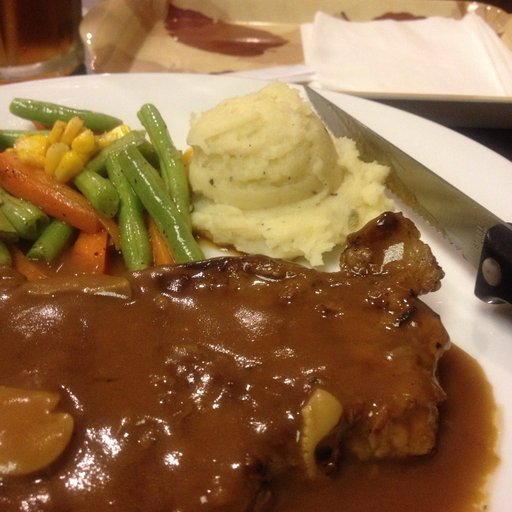

In [7]:
import random
from PIL import Image

# random.seed(42)
#1. Get image dir
image_path_list = list(image_path.glob("*/*/*.jpg"))

#2. Pick a random image path

random_img_path = random.choice(image_path_list)

#3. Get class from path name
image_class = random_img_path.parent.stem

#4. OPen img from pill
img = Image.open(random_img_path)

#5 Print meta data
print(f'Random img path {random_img_path}')
print(f'Img class {image_class}')
print(f'Height: {img.height}')
print(f'Height: {img.width}')

img

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

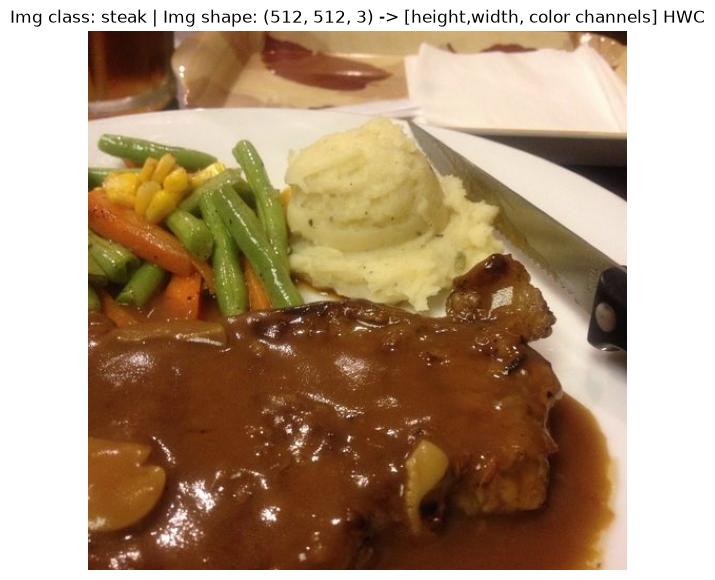

In [8]:
import matplotlib.pyplot as plt
import numpy as np 


img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f'Img class: {image_class} | Img shape: {img_as_array.shape} -> [height,width, color channels] HWC')

plt.axis(False)

## 3. Transforming data
Để có thể sử dụng các bức ảnh này trong huấn luyện model, thì mình cần phải làm các bước như ni:

1.Đưa các target thành mảng tensor (cổ điển - tôn trọng)

2.Đưa nó về dạng `torch.utils.data.Dataset`và sau đó chia chúng thành bó bunch of image (dataloader) chuyển bằng `torch.utils.data.DataLoader` dễ hiểu súc tích là đưa từ ảnh thật thành `Dataset` và biến chúng thành bó `DataLoader`


In [9]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


## 3.1 Transform data with `torchvision.transform`

Chuyển ảnh về tensor nhe https://docs.pytorch.org/vision/0.8/transforms.html


In [10]:
# Write a transform

# Piplne
data_transform = transforms.Compose([
    # Resize img 64 x 64
    transforms.Resize(size=(64,64)),

    #Flip random horizontal
    transforms.RandomHorizontalFlip(p=0.5),

    #Turn img into a torch tensor (HWC --> CHW)
    transforms.ToTensor()
])

In [11]:
data_transform(img).shape

torch.Size([3, 64, 64])

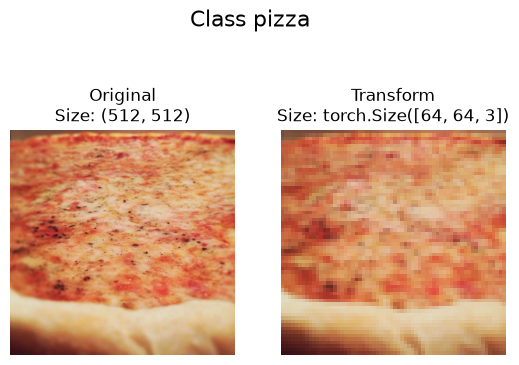

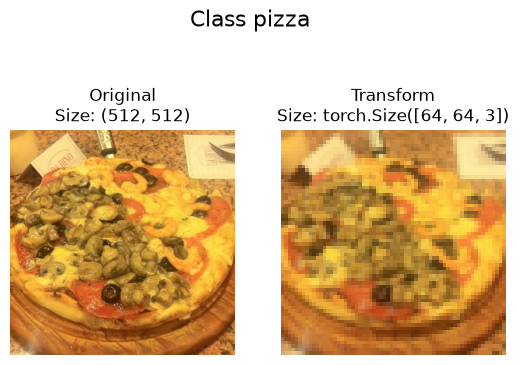

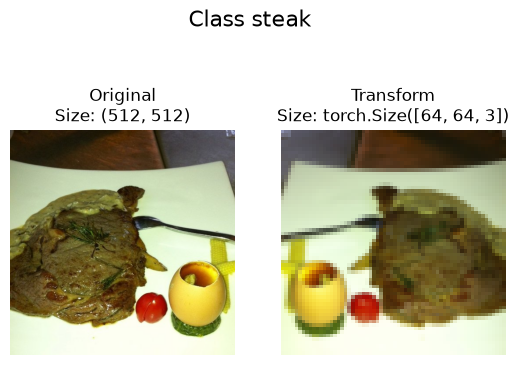

In [12]:
def plot_transform_img (image_paths: list, transform, n = 3, seed = None):
    
    if seed:
        random.seed(seed)
    random_img_paths_with_n_sample = random.sample(image_paths, k=n)

    for image_path in random_img_paths_with_n_sample:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f'Original\nSize: {f.size}')
            ax[0].axis(False)

            #Transform and plot target img

            transforms_img = transform(f).permute(1,2,0) # đổi từ CHW ngược về HWC
            ax[1].imshow(transforms_img)
            ax[1].set_title(f'Transform\nSize: {transforms_img.shape}')
            ax[1].axis('off')
            fig.suptitle(f'Class {image_path.parent.stem}', fontsize=16)

plot_transform_img(image_paths=image_path_list,transform=data_transform,n=3,seed=42)


## 4. Option 1: Loading img data using `ImageFolder`

Mình có thể load ảnh trong phân loại dữ liệu `torchvision.datasets.ImageFolder`

In [13]:
# Use ImageFolder to create dataset
from torchvision import datasets

train_data = datasets.ImageFolder(root=train_dir, transform=data_transform,target_transform=None) 
test_data = datasets.ImageFolder(root=test_dir,transform=data_transform)


train_data,test_data



(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [14]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [15]:
# Get class name as list
class_names = train_data.classes
class_names


['pizza', 'steak', 'sushi']

In [16]:

class_names_dict = train_data.class_to_idx
class_names_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [17]:
len(train_data), len(test_data)

(225, 75)

In [18]:
train_data.samples[:10]

[('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1033251.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1044789.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1089334.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1105700.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/12301.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1285298.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/138855.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1412034.jpg', 0),
 ('data/pizza_steak_sushi/train/pizza/1524655.jpg', 0)]

In [19]:
img, label =train_data[0]

print(f'Image tensor: {img}')

print(f'Image shape: {img.shape}')

print(f'Image data type: {img.dtype}')

print(f'Image label: {label}')

print(f'Image label: {type(label)}')

print(f'Class name of Image : {class_names[label]}')

Image tensor: tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.01

Original: torch.Size([3, 64, 64]) 
After permute: torch.Size([64, 64, 3])


Text(0.5, 1.0, 'pizza')

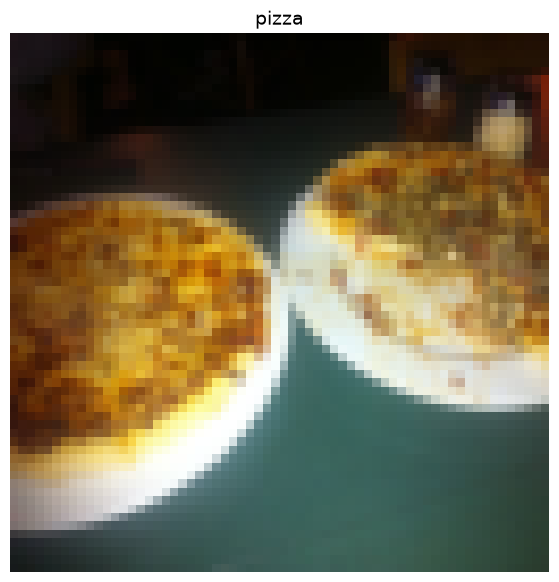

In [20]:
# Visualize Vì imshow nhận là HWC vì vậy cần chuyền CHW --> HWC

print(f'Original: {img.shape} ')

print(f'After permute: {img.permute(1,2,0).shape}')


plt.figure(figsize=(10,7))

plt.imshow(img.permute(1,2,0))
plt.axis(False)

plt.title(class_names[label], fontsize=14)


## 4.1 Turn loaded images into `DataLoader`'s 

A `DataLoader` cái ni giúp mình đưa `Dataset` thành dạng **iterable** chia thành bó để loop `batch_size` images at a time.


In [21]:
import os 
os.cpu_count()

8

In [22]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, num_workers=1,shuffle=True)

test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, num_workers=1,shuffle=False)



In [23]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [24]:
img, label = next(iter(train_dataloader))

print(f'Image shape: {img.shape}')
print(f'Label shape: {label.shape}')

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


## 5. Option 2: Loading data with custom `Dataset` 

1. Phù hợp cho việc lấy ảnh từ file 
2. Lấy class name từ dataset nè
3. Muốn class name lưu dạng dictoinary

Pros: 
* Tạo `dataset` vô tư hầu hết các thứ


Cos:
* Tạo đủ thứ `dataset` đó nhưng chưa chắc nó hoạt động nhe
* Việc chơi với lửa (custom dataset) thường có xu hướng ăn lỗi về mặt hiệu xuất 

In [25]:
import os 
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset

from torchvision import transforms

from typing import Tuple, Dict, List



In [26]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Taọ một func helper để hỗ trợ lấy class names

Func sẽ làm:
1. get class_name using `os.scandir()`
2. Có một lỗi sẽ xuất hiện nếu class names đó không được tìm thấy (nếu nó xảy ra thì có thể mình bị lỗi ở cấu trúc file)
3. Đưa class name vào một dict và list sau đó trả về.

In [27]:
target_directory = train_dir

print(f'Target dir: {target_directory}')

class_names_found =sorted([entry.name for entry in list(os.scandir(target_directory))])

class_names_found

Target dir: data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [28]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:

    # Get the class name by scanning tar get directory
    
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f'Could not find any classes in {directory}... check up file structure')
    class_to_idx = {class_name: i for i, class_name in enumerate(classes)}    
    return classes,class_to_idx

In [29]:
class_names,class_to_idx = find_classes(target_directory)
class_names,class_to_idx 

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Tạo 1 custom `Dataset` thay vì ImageFolder

1. Subclass `torch.utils.data.Dataset`
2. Init our subclass with a target directory
3. Tạo vài attribute để dễ quản lý
    * paths - paths (đường dẫn của ảnh)
    * transform - (một luồn pipeline xử lý data)
    * classes - lưu label
    * class_to_idx - lưu index của label
4. Tạo func load `img`
5. Ghi lại hàm `__len()__` để trả về theo đúng ý mình.
6. Ghi đè lại hàm `__getitem()__` optional nhe

In [30]:
from torch.utils.data import Dataset

class ImageFolderCustom(Dataset):
    def __init__(self, target_dir: str,transform=None):
        # Get all img path
        self.paths= list(pathlib.Path(target_dir).glob("*/*.jpg"))
        # Sst up transform
        self.transform = transform

        #Create attribute tu save classes, class_to_idx
        self.classes, self.class_to_idx = find_classes(target_dir)
    def load_image(self, index: int) -> Image.Image:
        "Mở ảnh bằng path được load qua transform"
        image_path = self.paths[index]
        return Image.open(image_path)
    
    def __len__(self) -> int:
        "Trả về độ dài của total sample"
        return len(self.paths)
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor: int]:
        "Return 1 sample of data and label (X,y)"
        img = self.load_image(index)
        class_name = self.paths[index].parent.name 
        class_idx = self.class_to_idx[class_name]

        #Transform if necesssary

        if self.transform:
            return self.transform(img), class_idx # return data, label (x,y)
        else:
            return img,class_idx # return un transform image and label
        



In [31]:
img,label = train_data[0]
img

tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0902, 0.0902, 0.

In [32]:
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


test_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])



In [33]:
train_data_custom = ImageFolderCustom(target_dir=train_dir,transform=train_transform)

test_data_custom = ImageFolderCustom(target_dir=test_dir, transform=test_transform)

In [34]:
train_data_custom,test_data_custom

(<__main__.ImageFolderCustom at 0x7fd84aa99880>,
 <__main__.ImageFolderCustom at 0x7fd84abb9370>)

In [35]:
len(train_data), len(train_data_custom)

(225, 225)

In [36]:
len(test_data), len(test_data_custom)

(75, 75)

In [37]:
train_data.class_to_idx, train_data.classes

({'pizza': 0, 'steak': 1, 'sushi': 2}, ['pizza', 'steak', 'sushi'])

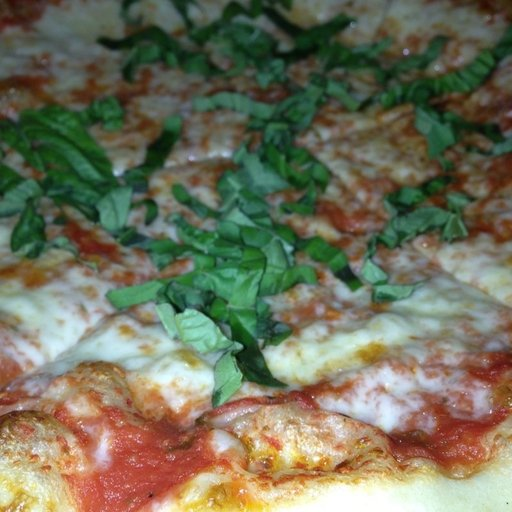

In [38]:
train_data_custom.load_image(0)

### 5.3 Tạo func để bốc ngẫu nhiên ảnh

In [39]:
def display_random_img (dataset: torch.utils.data.Dataset,
                        classes: List[str]=None,
                        n: int = 10,
                        display_shape: bool =True,
                        seed: int = None):
    if n > 10:
        n = 10
        display_shape = False
        print(f'For display Purpose, do not set n higher than 10')
    if seed:
        random.seed(seed)


    random_samples_idx = random.sample(range(len(dataset)), k=n)

    plt.figure(figsize=(16,8))


    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        targ_image_adjust = targ_image.permute(1,2,0)

        plt.subplot(1,n,i+1)
        plt.imshow(targ_image_adjust)
        plt.axis(False)
        if classes:
            title = f"Class: {classes[targ_label]}"
            if display_shape:
                title = title + f'\nshape: {targ_image_adjust.shape}'
        plt.title(title)


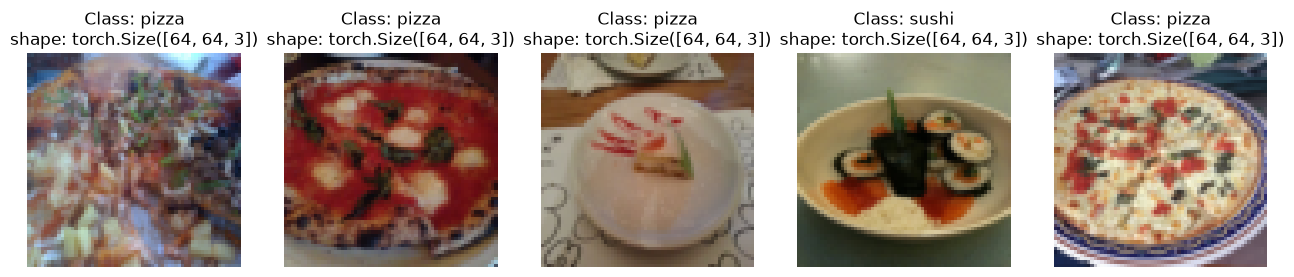

In [40]:
display_random_img(train_data,n=5, classes=class_names, seed=None)

In [41]:
print(type(train_data_custom.transform))

<class 'torchvision.transforms.transforms.Compose'>


For display Purpose, do not set n higher than 10


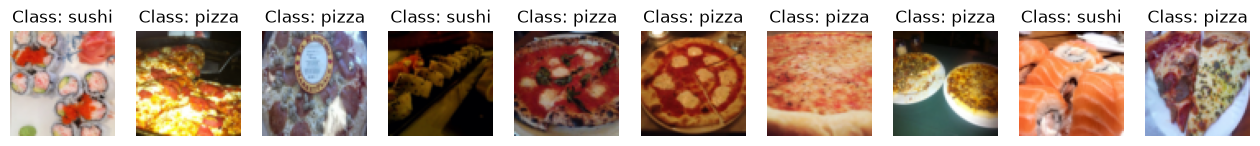

In [42]:
display_random_img(train_data_custom, n=20,classes=class_names,seed=42)

## 5.4 Turn custom loaded images into DataLoader 'S

In [43]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_custom =  DataLoader(dataset=train_data_custom, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
test_dataloader_custom = DataLoader(dataset=test_data_custom, batch_size=BATCH_SIZE,num_workers=NUM_WORKERS ,shuffle=False)
train_dataloader_custom,test_dataloader_custom


(<torch.utils.data.dataloader.DataLoader at 0x7fd948f0e9f0>,
 <torch.utils.data.dataloader.DataLoader at 0x7fd9490c5a30>)

In [44]:
#Get Image and label
img_custom, label_custom = next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Other form of transform 
https://docs.pytorch.org/vision/main/auto_examples/transforms/plot_transforms_illustrations.html

Có nhiều kiểu thay đổi dữ liệu để mô hình có thể học đa dạng hơn (vd: xoay ngang dọc nè, zoom in /out)

In [45]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])


test_transform = transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])



In [46]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/train/pizza/2821048.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/618348.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/300869.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2426686.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3281494.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3821701.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3338774.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1899785.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1524655.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/715169.jpg')]

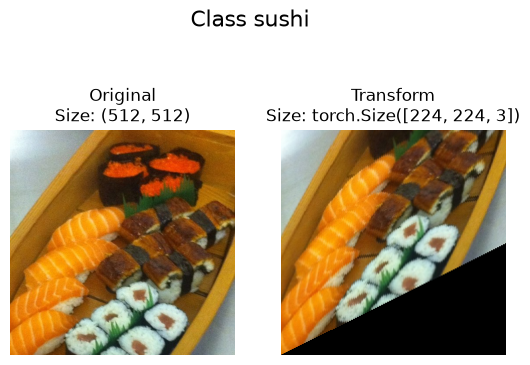

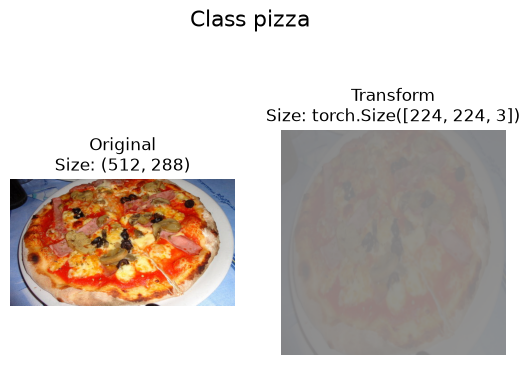

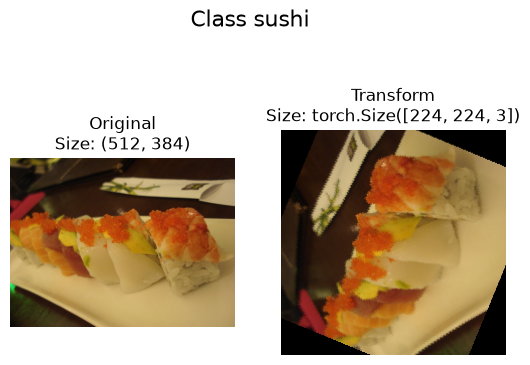

In [47]:
plot_transform_img(image_paths=image_path_list,transform=train_transform, n=3,seed=None)

## 7. Làm tí model

In [48]:
single_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])



In [49]:
from torchvision import datasets

train_data_simple = datasets.ImageFolder(root=train_dir,transform=single_transform)

test_data_simple = datasets.ImageFolder(root=test_dir, transform=single_transform)


import os
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader_simple = DataLoader(dataset=train_data_simple, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)


test_dataloader_simple = DataLoader(dataset=test_data_simple, batch_size=BATCH_SIZE,shuffle=False, num_workers=NUM_WORKERS)



In [50]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3,stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*13*13, out_features=output_shape)
        )
    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x
        


In [51]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [52]:
device

'cuda'

### 7.1 Tìm shape cho input cuối sau các phép chập


In [53]:
image_batch, label_batch = next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [54]:
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0047e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7979e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1815e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1470e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.3248e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

In [55]:
from torchinfo import summary

summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

In [58]:
def train_step(model: torch.nn.Module,
                dataloader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                optimizer: torch.optim.Optimizer,
                device=device):

    model.train()

    train_loss, train_acc = 0,0

    #Loop through dataloader

    for batch, (X,y) in enumerate(dataloader):
        #send data to target device
        X,y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)

        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)

    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc


In [59]:
def test_step (model: torch.nn.Module,
                dataloader: torch.utils.data.DataLoader,
                loss_fn: torch.nn.Module,
                device=device):

    model.eval()
    test_loss, test_acc = 0 ,0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)

            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)

            test_acc += ((test_pred_labels==y).sum().item()/ len(y))
            

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc /len(dataloader)

    return test_loss,test_acc


In [62]:
from tqdm.auto import tqdm
def train (model: torch.nn.Module,
            train_dataloader: torch.utils.data.DataLoader,
            test_dataloader: torch.utils.data.DataLoader,
            optimizer: torch.optim.Optimizer,
            loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
            epochs: int = 5,
            device=device):
	results = {"train_loss": [],
			"train_acc": [],
			"test_loss": [],
			"test_acc": []} 
	for epoch in tqdm(range(epochs)):
		train_loss, train_acc = train_step(model=model, dataloader=train_dataloader, loss_fn=loss_fn,optimizer=optimizer, device=device)

		test_loss, test_acc = test_step(model=model, dataloader=test_dataloader, loss_fn=loss_fn, device=device)

		print(f'Epoch: {epoch} | Train loss:  {train_loss:.4f} | Train accuracy: {train_acc:.4f}% | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}%')


		results["train_loss"].append(train_loss)
		results["train_acc"].append(train_acc)
		results["test_loss"].append(test_loss)
		results["test_acc"].append(test_acc)

	return results


In [65]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

model_0 = TinyVGG(input_shape=3,hidden_units=10, output_shape=len(train_data.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)


from timeit import default_timer as timer

start_time = timer()

model_0_results = train(model=model_0, 
						train_dataloader=train_dataloader_simple, 
						test_dataloader=test_dataloader_simple, 
						optimizer=optimizer, 
						loss_fn=loss_fn, 
						epochs=NUM_EPOCHS)
end_time = timer()

print(f'Total time train: {end_time - start_time:.3f} seconds')

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:00<00:02,  1.81it/s]

Epoch: 0 | Train loss:  1.1063 | Train accuracy: 0.3047% | Test loss: 1.0983 | Test accuracy: 0.3011%


 40%|████      | 2/5 [00:01<00:01,  1.85it/s]

Epoch: 1 | Train loss:  1.0998 | Train accuracy: 0.3281% | Test loss: 1.0697 | Test accuracy: 0.5417%


...

Epoch: 2 | Train loss:  1.0869 | Train accuracy: 0.4883% | Test loss: 1.0809 | Test accuracy: 0.4924%


 80%|████████  | 4/5 [00:02<00:00,  1.88it/s]

Epoch: 3 | Train loss:  1.0846 | Train accuracy: 0.4023% | Test loss: 1.0606 | Test accuracy: 0.5729%


100%|██████████| 5/5 [00:02<00:00,  1.86it/s]

Epoch: 4 | Train loss:  1.0662 | Train accuracy: 0.4219% | Test loss: 1.0658 | Test accuracy: 0.5644%
Total time train: 2.694 seconds


In [66]:
def plot_curves(results: Dict[str, List[float]]):
	loss = results["train_loss"]
	test_loss = results["test_loss"]

	acc = results["train_acc"]
	test_acc = results["test_acc"]

	epochs = range(len(results["train_loss"]))

	plt.figure(figsize=(15,7))

	plt.subplot(1,2,1)
	plt.plot(epochs, loss, label='train_loss')
	plt.plot(epochs, test_loss, label='test_loss')
	plt.title("Loss")
	plt.xlabel("Epochs")
	plt.legend()
	plt.subplot(1,2,2)
	plt.plot(epochs, acc, label='train_acc')
	plt.plot(epochs, test_acc, label='test_acc')
	plt.title("Accuracy")
	plt.xlabel("Epochs")
	plt.legend();
	

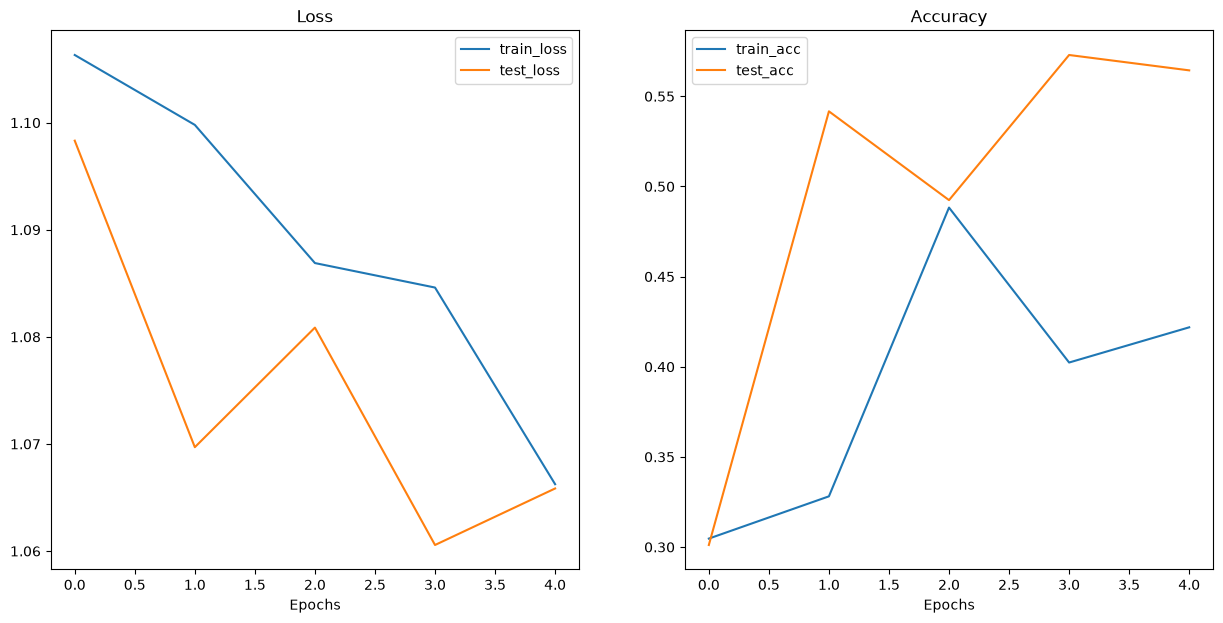

In [67]:
plot_curves(model_0_results)

## 8.Tham khảo hướng giải quyết
https://www.learnpytorch.io/04_pytorch_custom_datasets/#81-how-to-deal-with-overfitting

## 9.0 Improving time

In [68]:
from torchvision import transforms

train_transform_trivial = transforms.Compose([transforms.Resize(size=(64,64)),
												transforms.TrivialAugmentWide(num_magnitude_bins=31),
												transforms.ToTensor()
])

test_transform_simple = transforms.Compose([transforms.Resize(size=(64,64)),
											transforms.ToTensor()])

In [70]:
from torchvision import datasets
train_data_augmented = datasets.ImageFolder(root=train_dir,transform=train_transform_trivial)

test_data_simple = datasets.ImageFolder(root=test_dir, transform=test_transform_simple)

In [71]:
import os 
from torch.utils.data import DataLoader
BATCH_SIZE = 32 	
NUM_WORKERS = os.cpu_count()

torch.manual_seed(42)

train_dataloader_augmented = DataLoader(dataset=train_data_augmented, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset=test_data_simple, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)


In [72]:
torch.manual_seed(42)

model_1 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [74]:
torch.manual_seed(42)

torch.cuda.manual_seed(42)

NUM_EPOCHS = 5

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

from timeit import default_timer as timer

start_time = timer()

model_1_results = train(model=model_1, 
						train_dataloader=train_dataloader_augmented,
						test_dataloader=test_dataloader_simple, 
						optimizer=optimizer,loss_fn=loss_fn, 
						epochs=NUM_EPOCHS, device=device)

end_time = timer()

print(f'Total time train: {end_time - start_time:.3f} seconds')


 20%|██        | 1/5 [00:00<00:02,  1.70it/s]

Epoch: 0 | Train loss:  1.1045 | Train accuracy: 0.2500% | Test loss: 1.1016 | Test accuracy: 0.2604%


 40%|████      | 2/5 [00:01<00:01,  1.70it/s]

Epoch: 1 | Train loss:  1.0760 | Train accuracy: 0.4258% | Test loss: 1.1317 | Test accuracy: 0.2604%


 60%|██████    | 3/5 [00:01<00:01,  1.64it/s]

Epoch: 2 | Train loss:  1.0730 | Train accuracy: 0.4258% | Test loss: 1.1705 | Test accuracy: 0.2604%


 80%|████████  | 4/5 [00:02<00:00,  1.69it/s]

Epoch: 3 | Train loss:  1.1222 | Train accuracy: 0.3047% | Test loss: 1.1541 | Test accuracy: 0.2604%


100%|██████████| 5/5 [00:02<00:00,  1.72it/s]

Epoch: 4 | Train loss:  1.0734 | Train accuracy: 0.4688% | Test loss: 1.1495 | Test accuracy: 0.2708%
Total time train: 2.916 seconds


In [75]:
model_1_results

{'train_loss': [1.1045036166906357,
  1.076003685593605,
  1.072985902428627,
  1.122214913368225,
  1.0733592584729195],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.46875],
 'test_loss': [1.101592222849528,
  1.1316659450531006,
  1.1705313920974731,
  1.154090166091919,
  1.1494938135147095],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2708333333333333]}

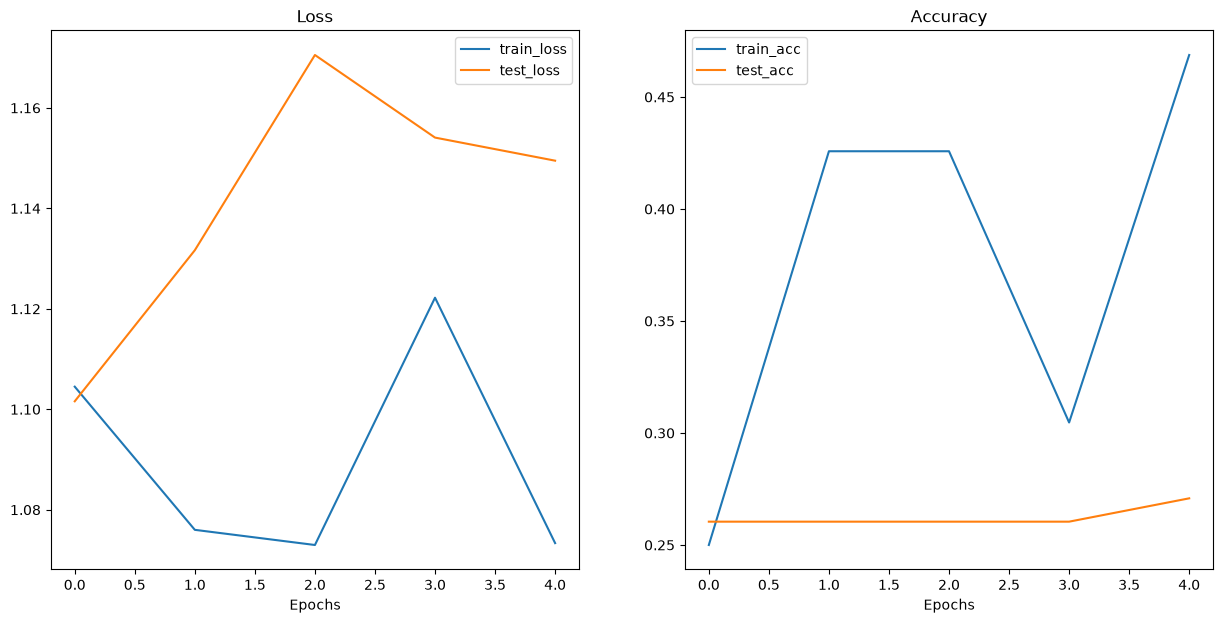

In [76]:
plot_curves(model_1_results)

In [81]:
# Custom predict
import requests

custom_image_path = data_path / "04-pizza-dad.jpeg"

if not custom_image_path.is_file():
	with open(custom_image_path, "wb") as f:
		request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
		f.write(request.content)
else:
	print(f'{custom_image_path} is already exists')


In [84]:
import torchvision
custom_image_uint8 = torchvision.io.read_image(str(custom_image_path))
custom_image_uint8.shape

torch.Size([3, 4032, 3024])

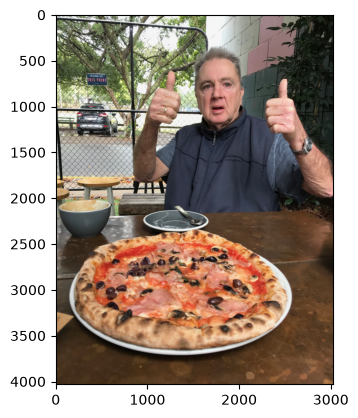

In [85]:
plt.imshow(custom_image_uint8.permute(1,2,0))

In [86]:
model_1.eval()
with torch.inference_mode():
	model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [90]:
#Load custom img convert to torch.float32
custom_img = torchvision.io.read_image(str(custom_image_path)).type(torch.float32) /255
custom_img

tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..., 0.0549, 0.0510, 0.

In [93]:
#Transform img
custom_img_transform = transforms.Compose([
											transforms.Resize(size=(64,64))
])

custom_image_transformed = custom_img_transform(custom_img)
custom_image_transformed.shape


torch.Size([3, 64, 64])

In [ ]:
# An error is raised because we loss the batch size
model_1.eval()
with torch.inference_mode():
	model_1(custom_image_transformed.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x169 and 1690x3)

In [99]:

model_1.eval()
with torch.inference_mode():
	custom_img_pred = model_1(custom_image_transformed.unsqueeze(0).to(device))
custom_img_pred

tensor([[ 0.0632,  0.0364, -0.2188]], device='cuda:0')

In [102]:
custom_image_probs = custom_img_pred.argmax(dim=1).item()
class_names[custom_image_probs]

'pizza'

In [107]:
def pred_and_plot_img(model: torch.nn.Module, image_path: str, class_names: List[str] = None, transforms=None, device=device):
	target_image = torchvision.io.read_image(str(image_path)).type(torch.float32) /255

	if transforms:
		target_image = transforms(target_image)
	
	model.to(device)

	model.eval()

	with torch.inference_mode():
		target_image = target_image.unsqueeze(0)

		target_image_pred = model(target_image.to(device))

	target_image_prob = torch.softmax(target_image_pred, dim=1)
	target_image_label = torch.argmax(target_image_prob,dim=1)

	plt.imshow(target_image.squeeze().permute(1,2,0))
	
	if class_names:
		title = f'Pred: {class_names[target_image_label.cpu()]} | prob: {target_image_prob.max().cpu():.3f}'
	else:
		title = f'Pred: {target_image_label} | prob: {target_image_prob.max().cpu():.3f}'

	plt.title(title)
	plt.axis(False)




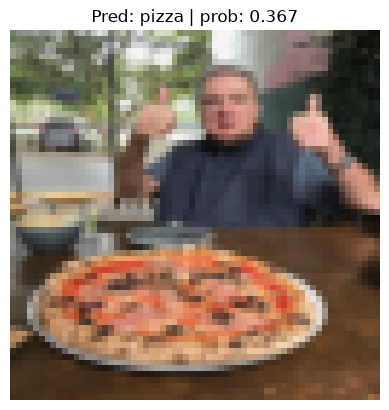

In [108]:
pred_and_plot_img(model=model_1,
					image_path=custom_image_path,
					class_names=class_names, 
					transforms=custom_img_transform,
					device=device)